# Correlating C02 Emissions and Global Temperature Anomalies

## Import Modules and Define variables

In [82]:
import plotly.express as px
import pandas as pd

import os

# HTML Full Output Path
bar_output_filename = "plotly_bar_chart.html"
bar_full_path = os.path.join(os.getcwd(), bar_output_filename)

line_output_filename = "plotly_line_chart.html"
line_full_path = os.path.join(os.getcwd(), line_output_filename)

scatter_output_filename = "plotly_scatter_chart.html"
scatter_full_path = os.path.join(os.getcwd(), scatter_output_filename)

# Define variables
start_year = 1850
end_year = 2021
START_YEAR = 1850
END_YEAR = 2021
coefficient_of_correlation=0


## Prepare Line Chart Yearly Emissions from Fossil Fuel Consumption and Cement Production (1850-2021)
This data is available for years 1751-2021, but filtered to 1850-2021 in order to compare with tempature anomoly data.

In [83]:
# Emissions data URL
# EMISSIONS_DATA = 'https://raw.githubusercontent.com/plotly/Figure-Friday/'\
#         'refs/heads/main/2025/week-21/global.1751_2021.csv'
EMISSIONS_DATA = '../../data/c02_emissions.csv'

# Read data from CSV file
df_emissions_1850_2021=  pd.read_csv(EMISSIONS_DATA,encoding='utf8',comment='#')

# Filter data for the specified year range (1850-2021)
df_filtered_emissions_1850_2021 = df_emissions_1850_2021[(df_emissions_1850_2021['Year'] >= START_YEAR) & (df_emissions_1850_2021['Year'] <= END_YEAR)]

# Set up CSV data column name constants for access by name
LINE_X_COL_NAME = 'Year'

# Name of column in emissions data CSV file
LINE_Y_COL_NAME = 'Total carbon emissions from fossil fuel consumption and cement production (million metric tons of C)'

# Create line chart using Plotly Express
line_fig = px.line(
    df_filtered_emissions_1850_2021,
    x=LINE_X_COL_NAME,
    y=LINE_Y_COL_NAME, 
    title='Yearly CO2 Emissions (1850-2021)',
    labels={LINE_Y_COL_NAME: "CO2 Emissions (MtC)"}
)

# Set the y-axis title
LINE_Y_AXIS_TITLE = "Million Metric Tons of Carbon"
line_fig.update_layout(yaxis_title=LINE_Y_AXIS_TITLE);



## Prepare Bar chart showing temperature anomalies by range of years 1850-2021

In [84]:
# BAR CHART: Temperature Anomalies by Year

# Temp Anomalies Filtering
TEMP_ANOMALIES_DATA = '../../data/global_temp_anomaly.csv'

# Read temp anomaly data
df_temp_anomaly = pd.read_csv(TEMP_ANOMALIES_DATA,comment='#',encoding='utf8')

# filter data for the specified year range (1850-2021)
df_filtered_temp_anomalies_1850_2021 = \
    df_temp_anomaly[(df_temp_anomaly\
    ['Year']>= START_YEAR) & (df_temp_anomaly['Year'] <= END_YEAR)]

# set up title constant
TEMP_ANOMALIES_TITLE = 'Avg Temperature Anomalies By Decade (1850-2021)' 

# set up filtering with column name constant
ANOMALY_COL_NAME = 'Anomaly'

# Create bins to feed bar chart

# Create a copy to add binned data to
df_filtered_temp_anomalies_1850_2021_COPY = df_filtered_temp_anomalies_1850_2021.copy()

# Create bins for 10 year time periods
bins = pd.interval_range(start=1850, end=2030, freq=10, closed='right')  # 10-year bins

# Add a new column to the DataFrame with the binned years named 'Year_bin'
# Pandas "cut" used to create bins
df_filtered_temp_anomalies_1850_2021_COPY['Year_bin'] = \
    pd.cut(df_filtered_temp_anomalies_1850_2021_COPY['Year'], bins)

# Group by bin and calculate mean temperature anomaly for each 10 year bin
grouped = df_filtered_temp_anomalies_1850_2021_COPY.\
    groupby('Year_bin', observed=True)['Anomaly'].mean().reset_index()
# print(grouped)

# Plot with Plotly Express
grouped['Year_bin_start'] = grouped['Year_bin'].apply(lambda x: int(x.left))

bar_fig = px.bar(grouped, x='Year_bin_start', y='Anomaly', title=TEMP_ANOMALIES_TITLE)

# bar_fig = px.bar(grouped, x='Year_bin', y='Anomaly', title='Avg Temperature Anomaly by Decade')
BAR_Y_AXIS_TITLE = "Avg Temp Anomaly\n(Degrees Celsius)"
BAR_X_AXIS_TITLE = "Start Year of Decade"
bar_fig.update_layout(xaxis_title=BAR_X_AXIS_TITLE);




## Correlation of Increasing C02 Emissions and Temperature Anomalies

In [85]:
# Scatterpolot and CORRELATION: Do temperature anomalies increase with increased C02 emissions


# Merge both DataFrames on 'Year'
df_merged = pd.merge(df_filtered_emissions_1850_2021, df_filtered_temp_anomalies_1850_2021, on='Year')

# Get list of years from merged
df_years = df_merged[['Year']].copy()

# Add century to df merged
df_merged['Century'] = ((df_merged['Year'] // 100) * 100).astype(str) + 's'
# # print(df_merged['Century'])


# Get Correllation Coefficient
coefficient_of_correlation = \
    df_filtered_emissions_1850_2021[LINE_Y_COL_NAME]\
        .corr(df_filtered_temp_anomalies_1850_2021[ANOMALY_COL_NAME])

# Add coefficient of correlation to title
TEMP_ANOMALIES_TITLE = f'Temperature Anomalies vs Carbon Emissions (1850–2021)'\
          f'<br>Correlation Coefficient: {coefficient_of_correlation:.2f}'
    
# Scatterplot using Express
scatterplot_x_fig = px.scatter(
    df_merged,
    x=LINE_Y_COL_NAME,
    y=ANOMALY_COL_NAME,
    color='Century', 
    labels={
        LINE_Y_COL_NAME: 'Fossil Fuel Emissions (MtC)',
        ANOMALY_COL_NAME: 'Temperature Anomaly (°C)'
    },
    title= TEMP_ANOMALIES_TITLE
);



## Show All Three Graphs: Line, Bar, Scatterplot

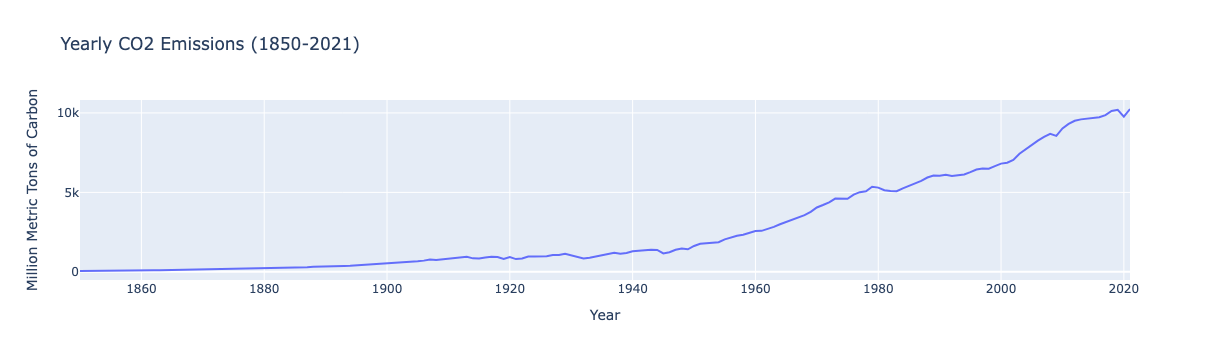

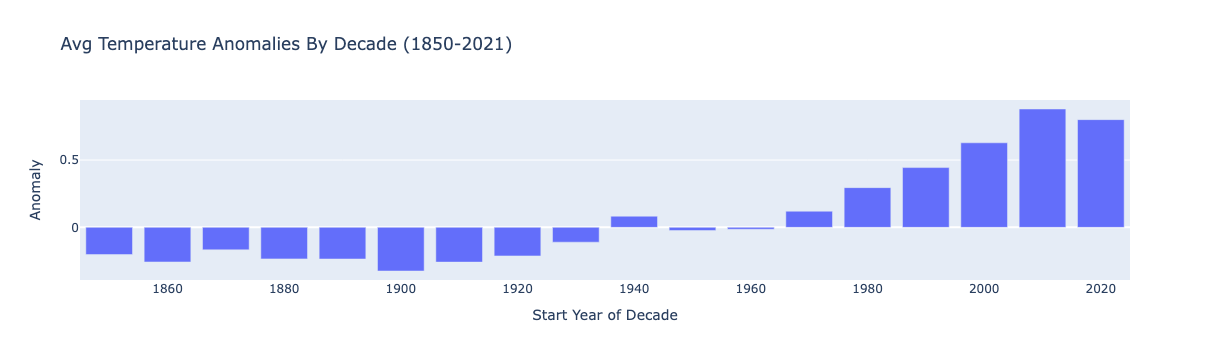

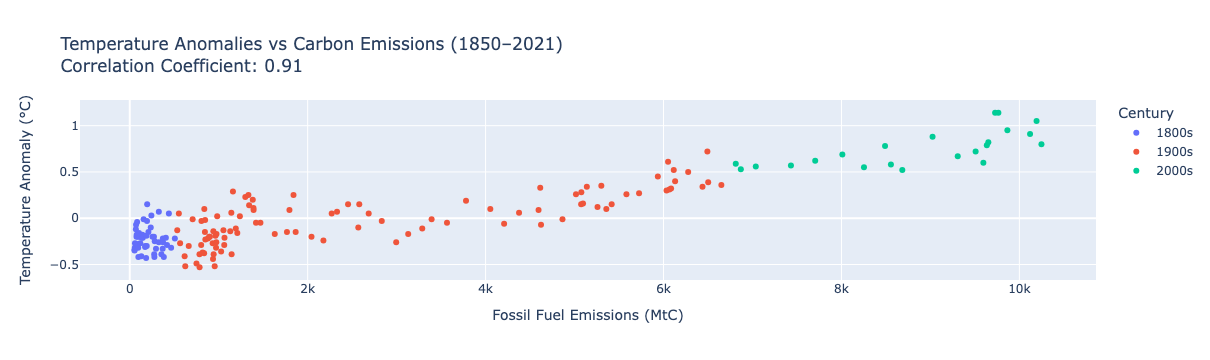

In [86]:

line_fig.show()
line_fig.write_html(line_full_path)

bar_fig.show()
bar_fig.write_html(bar_full_path)

scatterplot_x_fig.show()
scatterplot_x_fig.write_html(scatter_full_path)


# View the charts as HTML
Open the saved HTML file in your web browser

<a href="https://rebeccapeltz.github.io/data_analysis_code/CORRELATION/plotly_line_chart.html" target="_blank" rel="noopener noreferrer">Line Chart</a>

<a href="https://rebeccapeltz.github.io/data_analysis_code/CORRELATION/plotly_bar_chart.html" target="_blank" rel="noopener noreferrer">Bar Chart</a>

<a href="https://rebeccapeltz.github.io/data_analysis_code/CORRELATION/plotly_scatter_chart.html" target="_blank" rel="noopener noreferrer">Scatter Chart</a>